# Lab 03: Edge Detection Techniques and Their Impact on Classification (HAM10000)
**Runtime > Change runtime type > T4 GPU**, then **Runtime > Run all** (about 30-45 min).

Covers Task 1 (edge detectors), Task 2 (noise, Table 1), Task 3 (Canny parameters, Table 2), Tasks 4-5 (classification on Raw / Filtered / Edge sets, Table 3),
Task 6 (confusion matrices + bar chart), discussion answers, viva answers, and an auto-generated `report.md`.

**Edit only the CONFIG cell.** Use the same classes/dataset settings as in Labs 1 and 2 so the split is identical.

In [1]:
%pip -q install kagglehub datasets scikit-image tabulate

In [2]:
# ===================== CONFIG (EDIT HERE) =====================
MODEL_NAMES = ["resnet50", "densenet121"]   # CNN Model 1 and CNN Model 2 (torchvision names; use your best Lab 1 models)
BEST_FILTER = "Gaussian"                    # best filter from Lab 2: Average / Gaussian / Median / Sharpening / Sobel
EDGE_METHOD = "Canny"                       # edge set for Task 4: Sobel / Prewitt / Laplacian / LoG / Canny
CANNY_CFG   = "auto"                        # "auto" (chosen from Task 3) or a tuple (low, high, kernel), e.g. (50, 150, 3)

# keep IDENTICAL to Labs 1-2
IMG_SIZE = 128; SEED = 42; MAX_PER_CLASS = None; SELECTED_CLASSES = None
EPOCHS = 8; BATCH_SIZE = 64; LR = 1e-4
N_PER_CLASS_DEMO = 3          # images per class used in Tasks 2-3 statistics
NOISE_SIGMA = 25              # Gaussian noise std
SP_AMOUNT = 0.05              # salt-and-pepper fraction of pixels
OUT_DIR = "/content/lab03_results"
# ==============================================================

In [3]:
import os, random, time, pickle, glob, zipfile, warnings
import numpy as np, pandas as pd, cv2, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt, seaborn as sns
from concurrent.futures import ThreadPoolExecutor
from joblib import Parallel, delayed
from skimage.feature import hog
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             balanced_accuracy_score, confusion_matrix)
warnings.filterwarnings("ignore")
for d in ("runs", "figs"): os.makedirs(f"{OUT_DIR}/{d}", exist_ok=True)
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", dev, torch.cuda.get_device_name(0) if dev.type == "cuda" else "(enable a T4 GPU for speed)")
def set_seed(s): random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
def savefig(n): plt.savefig(f"{OUT_DIR}/figs/{n}.png", dpi=150, bbox_inches="tight")
pretty = {"resnet50": "ResNet50", "densenet121": "DenseNet121", "efficientnet_b0": "EfficientNet-B0", "vgg16": "VGG16", "mobilenet_v2": "MobileNetV2"}
ANS = {}   # answers collected for the report

Device: cuda Tesla T4


## 1. Data (same loader and split as Lab 2)

In [4]:
def _read(p):
    im = cv2.imread(p); return cv2.resize(cv2.cvtColor(im, cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

def load_ham():
    try:
        import kagglehub
        root = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
        meta = pd.read_csv(glob.glob(f"{root}/**/HAM10000_metadata.csv", recursive=True)[0])
        paths = {os.path.basename(p)[:-4]: p for p in glob.glob(f"{root}/**/*.jpg", recursive=True)}
        meta = meta[meta.image_id.isin(paths)].reset_index(drop=True)
        with ThreadPoolExecutor(8) as ex: X = np.stack(list(ex.map(_read, [paths[i] for i in meta.image_id])))
        print("Loaded from Kaggle mirror"); return meta[["image_id", "lesion_id", "dx"]], X
    except Exception as e:
        print("Kaggle route failed:", repr(e)[:150], "-> trying Hugging Face")
        from datasets import load_dataset, concatenate_datasets
        ds = load_dataset("marmal88/skin_cancer"); d = concatenate_datasets([ds[k] for k in ds.keys()])
        rows, imgs, seen = [], [], set()
        for r in d:
            if r["image_id"] in seen: continue
            seen.add(r["image_id"])
            imgs.append(cv2.resize(np.array(r["image"].convert("RGB")), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA))
            rows.append((r["image_id"], r["lesion_id"], r["dx"]))
        return pd.DataFrame(rows, columns=["image_id", "lesion_id", "dx"]), np.stack(imgs)

meta, X = load_ham()
if SELECTED_CLASSES:
    keep = meta.dx.isin(SELECTED_CLASSES).values; meta, X = meta[keep].reset_index(drop=True), X[keep]
if MAX_PER_CLASS:
    idx = np.sort(meta.groupby("dx", group_keys=False).apply(lambda g: g.sample(min(len(g), MAX_PER_CLASS), random_state=SEED)).index.values)
    meta, X = meta.iloc[idx].reset_index(drop=True), X[idx]
CLASSES = sorted(meta.dx.unique()); c2i = {c: i for i, c in enumerate(CLASSES)}
y = meta.dx.map(c2i).values; NC = len(CLASSES)
print(f"Images: {len(meta)} | classes ({NC}): {CLASSES} | counts: {dict(meta.dx.value_counts())}")

sg = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
rest, te_idx = next(sg.split(np.zeros(len(y)), y, meta.lesion_id.values))
sg2 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED)
a, b = next(sg2.split(np.zeros(len(rest)), y[rest], meta.lesion_id.values[rest]))
tr_idx, va_idx = rest[a], rest[b]
assert not (set(meta.lesion_id[tr_idx]) & set(meta.lesion_id[te_idx]))
print("train/val/test:", len(tr_idx), len(va_idx), len(te_idx))

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Loaded from Kaggle mirror
Images: 10015 | classes (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'] | counts: {'nv': np.int64(6705), 'mel': np.int64(1113), 'bkl': np.int64(1099), 'bcc': np.int64(514), 'akiec': np.int64(327), 'vasc': np.int64(142), 'df': np.int64(115)}
train/val/test: 7145 1429 1441


## 2. Filters (Lab 2) and edge detectors (Lab 3)

In [5]:
SHARP_K = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], np.float32)
def apply_filter(img, name):
    if name == "No Filter":  return img
    if name == "Average":    return cv2.blur(img, (5, 5))
    if name == "Gaussian":   return cv2.GaussianBlur(img, (5, 5), 1.5)
    if name == "Median":     return cv2.medianBlur(img, 5)
    if name == "Sharpening": return cv2.filter2D(img, -1, SHARP_K)
    if name == "Sobel":
        g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32)
        m = cv2.magnitude(cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3), cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3))
        return np.stack([np.clip(255 * m / (m.max() + 1e-6), 0, 255).astype(np.uint8)] * 3, -1)
    raise ValueError(name)

K_PX = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], np.float32)       # Prewitt Gx (Gy = transpose)
def gray32(img): return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32)
def sobel_gx(g): return cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3)
def sobel_gy(g): return cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3)
def sobel_mag(g): return cv2.magnitude(sobel_gx(g), sobel_gy(g))
def prewitt_mag(g): return cv2.magnitude(cv2.filter2D(g, cv2.CV_32F, K_PX), cv2.filter2D(g, cv2.CV_32F, K_PX.T))
def laplacian(g): return np.abs(cv2.Laplacian(g, cv2.CV_32F, ksize=3))
def log_edge(g, s=1.4): return np.abs(cv2.Laplacian(cv2.GaussianBlur(g, (0, 0), s), cv2.CV_32F, ksize=3))
def canny(g, lo, hi, k=3):
    g8 = np.clip(g, 0, 255).astype(np.uint8)
    if k and k > 1: g8 = cv2.GaussianBlur(g8, (k, k), 0)               # smoothing stage of Canny
    return cv2.Canny(g8, lo, hi).astype(np.float32)

DEFAULT_CANNY = (50, 150, 3)
DETS = ["Sobel", "Prewitt", "Laplacian", "LoG", "Canny"]
def det_map(name, g, cfg=DEFAULT_CANNY):
    if name == "Canny": return canny(g, *cfg)
    return {"Sobel": sobel_mag, "Prewitt": prewitt_mag, "Laplacian": laplacian, "LoG": log_edge}[name](g)
def otsu_abs(m):
    s = float(m.max()) + 1e-6
    t, _ = cv2.threshold(np.clip(255 * m / s, 0, 255).astype(np.uint8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return t * s / 255
def det_bin(name, g, thr=None, cfg=DEFAULT_CANNY):
    m = det_map(name, g, cfg); return (m > 0) if name == "Canny" else (m > thr)
def vis(m): m = np.abs(m); return np.clip(255 * m / (m.max() + 1e-6), 0, 255).astype(np.uint8)

def edge_scores(ref, test):
    """Compare a test edge map with a reference map (1-pixel tolerance)."""
    k = np.ones((3, 3), np.uint8)
    rd = cv2.dilate(ref.astype(np.uint8), k).astype(bool); td = cv2.dilate(test.astype(np.uint8), k).astype(bool)
    p = (test & rd).sum() / max(test.sum(), 1); r = (ref & td).sum() / max(ref.sum(), 1)
    n, _ = cv2.connectedComponents(test.astype(np.uint8), connectivity=8)
    return dict(Precision=p, Recall=r, F1=2 * p * r / max(p + r, 1e-9), Density=100 * test.mean(),
                Segments_per_1k=(n - 1) / max(test.sum(), 1) * 1000, EdgePixels=int(test.sum()))

# representative images: N per class
rs = np.random.RandomState(SEED)
sel = np.concatenate([rs.choice(np.where(y == c)[0], min(N_PER_CLASS_DEMO, (y == c).sum()), replace=False) for c in range(NC)])
print("Selected", len(sel), "images across", NC, "classes for Tasks 2-3")

Selected 21 images across 7 classes for Tasks 2-3


## Task 1: Comparative edge detection
Required figure: Original -> Sobel -> Prewitt -> Laplacian -> LoG -> Canny (one row per class, >= 3 classes).

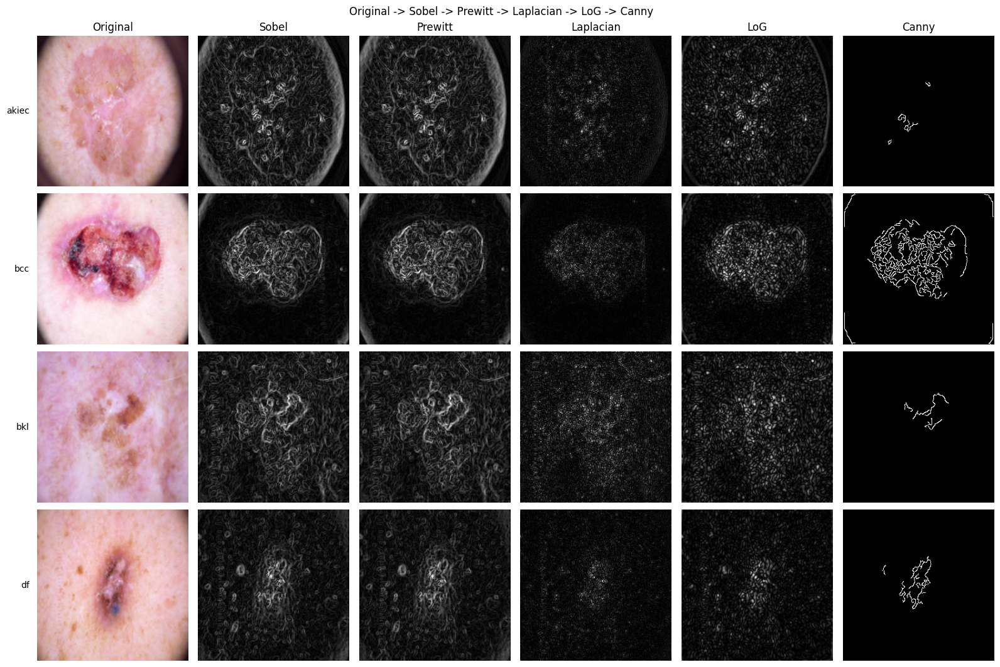

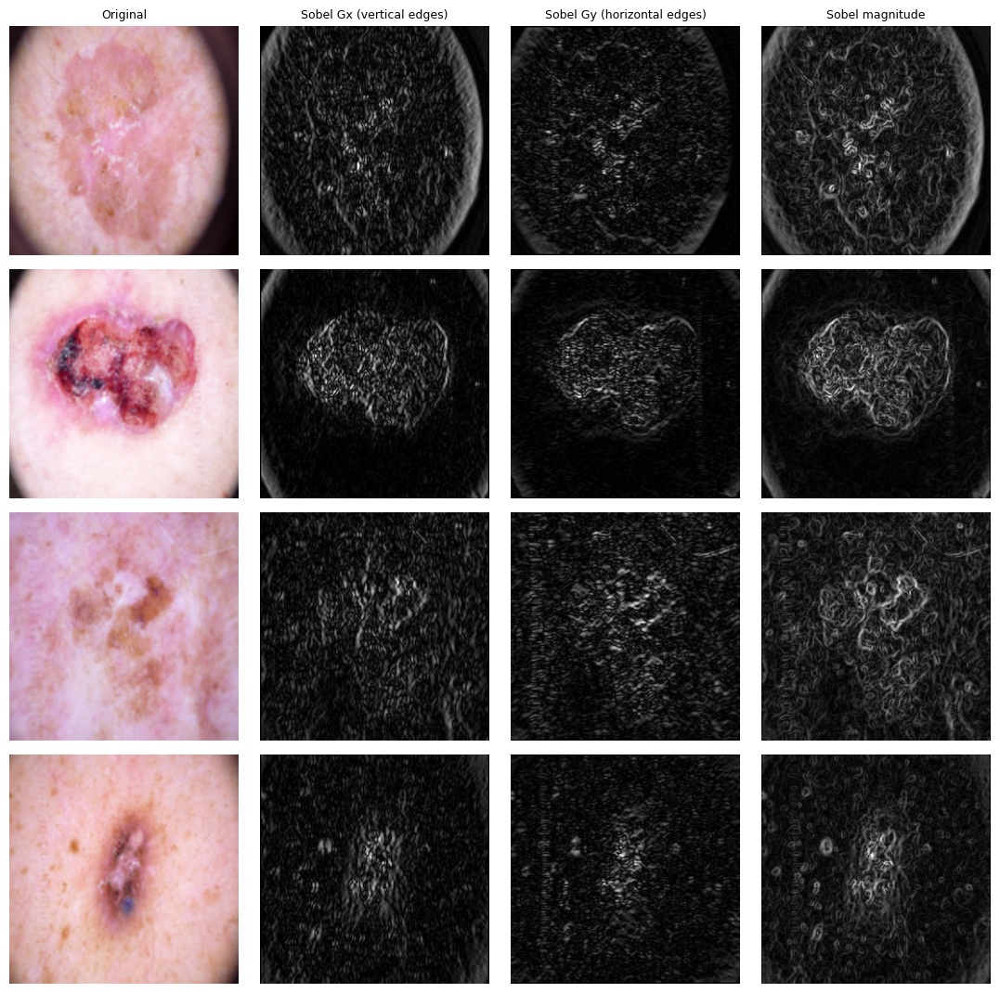

In [6]:
show_cls = list(range(min(NC, 4)))
if NC < 3: print("WARNING: task requires at least 3 classes")
rep = [np.where(y == c)[0][0] for c in show_cls]
big = lambda i: cv2.resize(X[i], (256, 256), interpolation=cv2.INTER_CUBIC)
cols = ["Original"] + DETS
fig, axs = plt.subplots(len(rep), 6, figsize=(16, 2.7 * len(rep))); axs = np.atleast_2d(axs)
for r, i in enumerate(rep):
    im = big(i); g = gray32(im)
    outs = [im] + [vis(det_map(d, g)) for d in DETS]
    for c, o in enumerate(outs):
        axs[r, c].imshow(o, cmap=None if c == 0 else "gray"); axs[r, c].axis("off")
        if r == 0: axs[r, c].set_title(cols[c])
    axs[r, 0].text(-0.05, 0.5, CLASSES[y[i]], transform=axs[r, 0].transAxes, ha="right", va="center")
plt.suptitle("Original -> Sobel -> Prewitt -> Laplacian -> LoG -> Canny"); plt.tight_layout(); savefig("task1_edge_detectors"); plt.show()

fig, axs = plt.subplots(len(rep), 4, figsize=(11, 2.7 * len(rep))); axs = np.atleast_2d(axs)
for r, i in enumerate(rep):
    g = gray32(big(i)); outs = [big(i), vis(sobel_gx(g)), vis(sobel_gy(g)), vis(sobel_mag(g))]
    for c, (o, t) in enumerate(zip(outs, ["Original", "Sobel Gx (vertical edges)", "Sobel Gy (horizontal edges)", "Sobel magnitude"])):
        axs[r, c].imshow(o, cmap=None if c == 0 else "gray"); axs[r, c].axis("off")
        if r == 0: axs[r, c].set_title(t, fontsize=9)
plt.tight_layout(); savefig("task1_sobel_components"); plt.show()

## Task 2: Effect of noise and preprocessing (Table 1)
Gaussian noise (sigma=25) and salt-and-pepper noise (5% of pixels). Inputs: original, noisy, noisy + Gaussian filter (5x5), noisy + Median filter (5).
Continuous edge maps are binarised with Otsu's threshold computed separately for each input (so smoothing is not penalised just for lowering gradient magnitude).
Edge quality = F1 of the edge map against the clean-image edge map (1 px tolerance). Noise sensitivity = fraction of detected edge pixels that are false edges (1 - precision).
Fragmentation = connected edge segments per 1000 edge pixels (higher = more broken/fragmented edges).

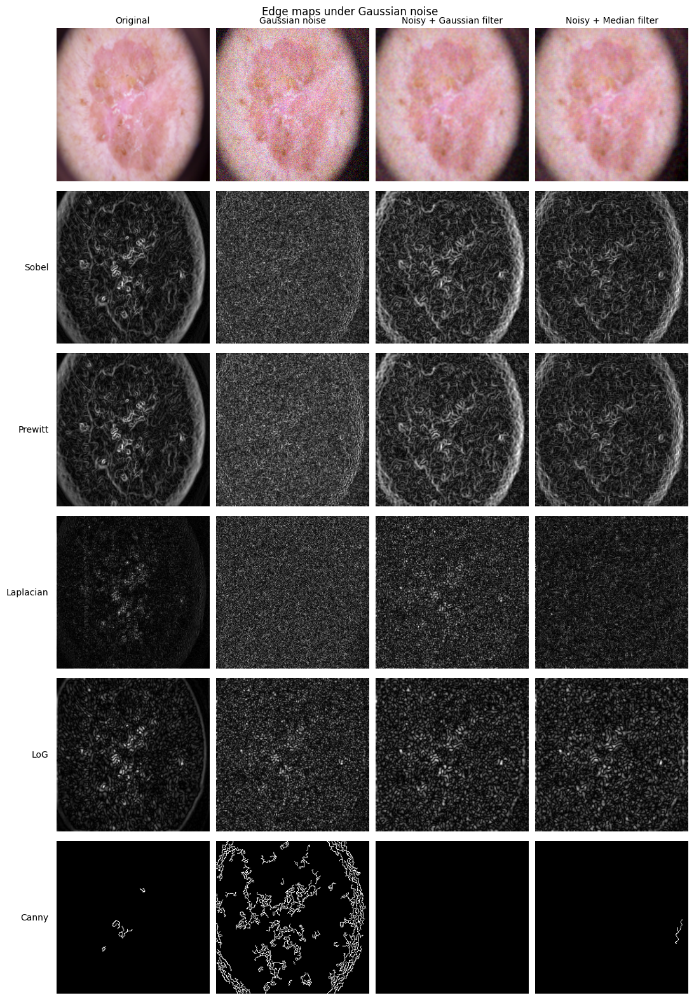

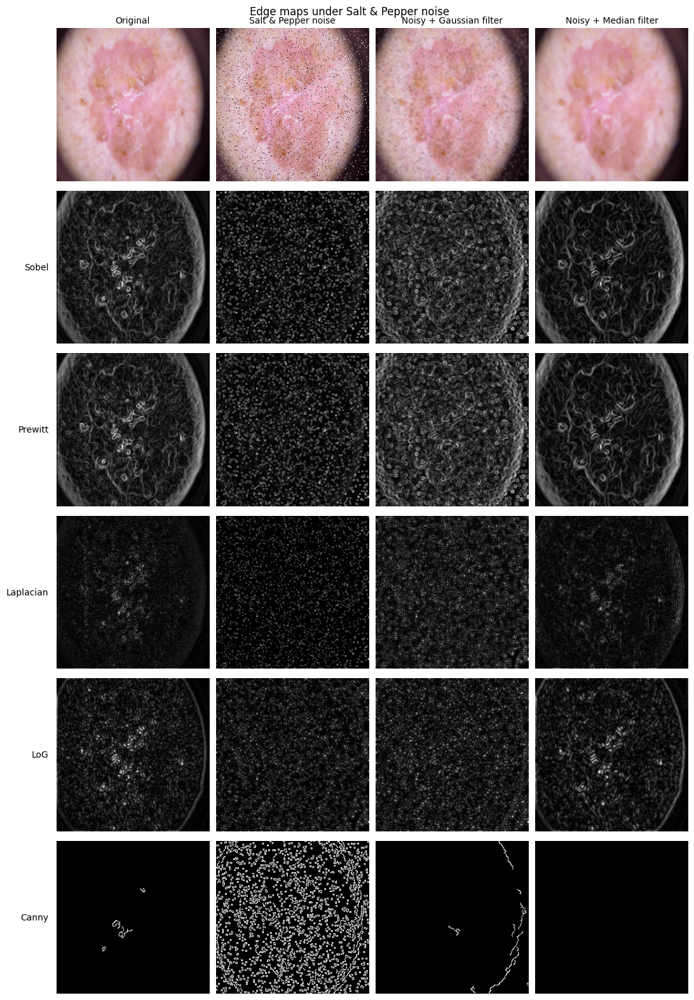

TABLE 1 (required rows)


,Edge Detector,Input,Noise Type,Preprocessing,Edge Quality,Noise Sensitivity,Observations
0,Sobel,Original,None,None,Reference (F1=1.00),-,"Clean reference; 16.1% edge pixels, 45 segments/1k px."
1,Sobel,Noisy,Gaussian,None,Fair (F1=0.55),High (57% false),57% of edge pixels are false edges (precision 0.43); recall 0.98 (missed/broken edges); density 2.3x clean; 51 segments/1k px.
2,Sobel,Noisy,Salt & Pepper,None,Poor (F1=0.45),High (62% false),62% of edge pixels are false edges (precision 0.38); recall 0.75 (missed/broken edges); density 1.6x clean; 61 segments/1k px.
3,Sobel,Noisy,Gaussian,Gaussian Filter,Good (F1=0.76),Moderate (28% false),28% of edge pixels are false edges (precision 0.72); recall 0.90 (missed/broken edges); density 1.5x clean; 38 segments/1k px. Filtering changed F1 by +0.21 vs unfiltered noisy input.
4,Sobel,Noisy,Salt & Pepper,Median Filter,Good (F1=0.80),Low (13% false),13% of edge pixels are false edges (precision 0.87); recall 0.80 (missed/broken edges); density 1.0x clean; 19 segments/1k px. Filtering changed F1 by +0.35 vs unfiltered noisy input.
5,Prewitt,Original,None,None,Reference (F1=1.00),-,"Clean reference; 16.3% edge pixels, 44 segments/1k px."
6,Laplacian,Original,None,None,Reference (F1=1.00),-,"Clean reference; 16.7% edge pixels, 172 segments/1k px."
7,LoG,Noisy,Gaussian,Gaussian Filter,Fair (F1=0.71),Moderate (38% false),38% of edge pixels are false edges (precision 0.62); recall 0.90 (missed/broken edges); density 1.6x clean; 73 segments/1k px. Filtering changed F1 by +0.05 vs unfiltered noisy input.
8,Canny,Original,None,Built-in smoothing,Reference (F1=1.00),-,"Clean reference; 2.2% edge pixels, 29 segments/1k px."
9,Canny,Noisy,Gaussian,Gaussian Filter,Poor (F1=0.33),High (40% false),40% of edge pixels are false edges (precision 0.60); recall 0.26 (missed/broken edges); density 0.3x clean; 21 segments/1k px. Filtering changed F1 by +0.02 vs unfiltered noisy input.


Full grid (every detector x noise x filter) saved to table1_full.csv; numeric summary:


,Edge Detector,Input,Noise Type,Preprocessing,F1,Precision,Recall,Density,DensityRatio,Segments_per_1k
0,Sobel,Original,None,None,1.000,1.000,1.000,16.094,1.000,44.685
1,Sobel,Noisy,Gaussian,None,0.554,0.427,0.984,37.310,2.318,50.599
2,Sobel,Noisy,Gaussian,Gaussian Filter,0.762,0.722,0.903,24.173,1.502,38.046
3,Sobel,Noisy,Gaussian,Median Filter,0.695,0.633,0.894,25.550,1.588,54.636
4,Sobel,Noisy,Salt & Pepper,None,0.453,0.380,0.749,25.450,1.581,61.344
5,Sobel,Noisy,Salt & Pepper,Gaussian Filter,0.594,0.496,0.900,32.873,2.043,33.728
6,Sobel,Noisy,Salt & Pepper,Median Filter,0.802,0.868,0.799,16.280,1.012,19.213
7,Prewitt,Original,None,None,1.000,1.000,1.000,16.301,1.000,44.365
8,Prewitt,Noisy,Gaussian,None,0.558,0.430,0.985,37.159,2.280,73.048
9,Prewitt,Noisy,Gaussian,Gaussian Filter,0.770,0.733,0.903,23.953,1.469,36.997


In [7]:
def add_gauss(img, rng, sigma=NOISE_SIGMA): return np.clip(img + rng.normal(0, sigma, img.shape), 0, 255).astype(np.uint8)
def add_sp(img, rng, amount=SP_AMOUNT):
    o = img.copy(); r = rng.random(img.shape[:2]); o[r < amount / 2] = 0; o[r > 1 - amount / 2] = 255; return o
GF = lambda a: cv2.GaussianBlur(a, (5, 5), 1.5); MF = lambda a: cv2.medianBlur(a, 5)
COND = [("Original", "None", "None"),
        ("Noisy", "Gaussian", "None"), ("Noisy", "Gaussian", "Gaussian Filter"), ("Noisy", "Gaussian", "Median Filter"),
        ("Noisy", "Salt & Pepper", "None"), ("Noisy", "Salt & Pepper", "Gaussian Filter"), ("Noisy", "Salt & Pepper", "Median Filter")]
def build_inputs(img, rng):
    ng, ns = add_gauss(img, rng), add_sp(img, rng)
    return dict(zip(COND, [img, ng, GF(ng), MF(ng), ns, GF(ns), MF(ns)]))

# visual: noisy + filtered images and edge maps (one figure per noise type)
demo_i = rep[0]; rng = np.random.default_rng(SEED); demo = build_inputs(cv2.resize(X[demo_i], (256, 256), interpolation=cv2.INTER_CUBIC), rng)
for noise in ["Gaussian", "Salt & Pepper"]:
    keys = [COND[0], ("Noisy", noise, "None"), ("Noisy", noise, "Gaussian Filter"), ("Noisy", noise, "Median Filter")]
    ttl = ["Original", f"{noise} noise", "Noisy + Gaussian filter", "Noisy + Median filter"]
    fig, axs = plt.subplots(6, 4, figsize=(11, 16))
    for c, k in enumerate(keys):
        axs[0, c].imshow(demo[k]); axs[0, c].set_title(ttl[c], fontsize=10); axs[0, c].axis("off")
        g = gray32(demo[k])
        for r, d in enumerate(DETS):
            axs[r + 1, c].imshow(vis(det_map(d, g)), cmap="gray"); axs[r + 1, c].axis("off")
            if c == 0: axs[r + 1, c].text(-0.05, 0.5, d, transform=axs[r + 1, c].transAxes, ha="right", va="center")
    plt.suptitle(f"Edge maps under {noise} noise"); plt.tight_layout(); savefig(f"task2_{noise.replace(' & ', '_').replace(' ', '')}"); plt.show()

# quantitative evaluation over all selected images
rng = np.random.default_rng(SEED); acc = []
for i in sel:
    inp = build_inputs(X[i], rng); g0 = gray32(inp[COND[0]])
    for d in DETS:
        thr = None if d == "Canny" else otsu_abs(det_map(d, g0)); ref = det_bin(d, g0, thr)
        for c in COND:
            gc = gray32(inp[c]); thr_c = None if d == "Canny" else otsu_abs(det_map(d, gc))
            acc.append(dict(Detector=d, Input=c[0], Noise=c[1], Preproc=c[2], **edge_scores(ref, det_bin(d, gc, thr_c))))
raw1 = pd.DataFrame(acc).groupby(["Detector", "Input", "Noise", "Preproc"], sort=False).mean().reset_index()
clean_dens = raw1[raw1.Input == "Original"].set_index("Detector").Density
raw1["DensityRatio"] = raw1.Density.values / clean_dens.loc[raw1.Detector].values

def q_label(r):
    if r.Input == "Original": return "Reference"
    return "Good" if r.F1 >= 0.75 else ("Fair" if r.F1 >= 0.5 else "Poor")
def s_label(r):
    if r.Input == "Original": return "-"
    fe = 1 - r.Precision; return "Low" if fe < 0.15 else ("Moderate" if fe < 0.4 else "High")
def obs(r):
    if r.Input == "Original": return f"Clean reference; {r.Density:.1f}% edge pixels, {r.Segments_per_1k:.0f} segments/1k px."
    base = raw1[(raw1.Detector == r.Detector) & (raw1.Noise == r.Noise) & (raw1.Preproc == "None")].iloc[0]
    s = (f"{100*(1-r.Precision):.0f}% of edge pixels are false edges (precision {r.Precision:.2f}); recall {r.Recall:.2f} "
         f"(missed/broken edges); density {r.DensityRatio:.1f}x clean; {r.Segments_per_1k:.0f} segments/1k px.")
    if r.Preproc != "None": s += f" Filtering changed F1 by {r.F1 - base.F1:+.2f} vs unfiltered noisy input."
    return s
t1 = raw1.copy()
t1["Edge Quality"] = t1.apply(lambda r: f"{q_label(r)} (F1={r.F1:.2f})", axis=1)
t1["Noise Sensitivity"] = t1.apply(lambda r: s_label(r) + ("" if r.Input == "Original" else f" ({100*(1-r.Precision):.0f}% false)"), axis=1)
t1["Observations"] = t1.apply(obs, axis=1)
t1 = t1.rename(columns={"Detector": "Edge Detector", "Preproc": "Preprocessing", "Noise": "Noise Type"})
T1_COLS = ["Edge Detector", "Input", "Noise Type", "Preprocessing", "Edge Quality", "Noise Sensitivity", "Observations"]
t1.to_csv(f"{OUT_DIR}/table1_full.csv", index=False)

REQ = [("Sobel", "Original", "None", "None"), ("Sobel", "Noisy", "Gaussian", "None"), ("Sobel", "Noisy", "Salt & Pepper", "None"),
       ("Sobel", "Noisy", "Gaussian", "Gaussian Filter"), ("Sobel", "Noisy", "Salt & Pepper", "Median Filter"),
       ("Prewitt", "Original", "None", "None"), ("Laplacian", "Original", "None", "None"), ("LoG", "Noisy", "Gaussian", "Gaussian Filter"),
       ("Canny", "Original", "None", "None"), ("Canny", "Noisy", "Gaussian", "Gaussian Filter"), ("Canny", "Noisy", "Salt & Pepper", "Median Filter")]
key = list(zip(t1["Edge Detector"], t1.Input, t1["Noise Type"], t1.Preprocessing))
t1_req = pd.concat([t1.iloc[[key.index(k)]] for k in REQ])[T1_COLS].reset_index(drop=True)
t1_req.loc[t1_req["Edge Detector"].eq("Canny") & t1_req.Input.eq("Original"), "Preprocessing"] = "Built-in smoothing"
pd.set_option("display.max_colwidth", 200); pd.set_option("display.width", 250)
print("TABLE 1 (required rows)"); display(t1_req)
t1_req.to_csv(f"{OUT_DIR}/table1_required.csv", index=False)
print("Full grid (every detector x noise x filter) saved to table1_full.csv; numeric summary:")
display(t1[["Edge Detector", "Input", "Noise Type", "Preprocessing", "F1", "Precision", "Recall", "Density", "DensityRatio", "Segments_per_1k"]].round(3))

## Task 3: Canny parameter analysis (Table 2)

,Configuration,Low Threshold,High Threshold,Kernel Size,Edge Quality,Number of Detected Edges (px/img),Density %,Segments/img,Noise robustness F1,Observation
0,Canny-1,30,100,3x3,Balanced,1000,6.10,20,0.321,Main lesion border and moderate texture retained with limited clutter.
1,Canny-2,50,150,3x3,Balanced,364,2.22,8,0.301,Main lesion border and moderate texture retained with limited clutter.
2,Canny-3,100,200,3x3,Sparse,100,0.61,3,0.434,Only strongest boundaries kept; fine texture and weak lesion borders may be lost.
3,Canny-4,50,150,5x5,Sparse,184,1.12,4,0.470,Only strongest boundaries kept; fine texture and weak lesion borders may be lost.
4,Canny-5,30,100,5x5,Balanced,600,3.66,14,0.407,Main lesion border and moderate texture retained with limited clutter.
5,Canny-6,100,200,5x5,Sparse,55,0.33,2,0.355,Only strongest boundaries kept; fine texture and weak lesion borders may be lost.


Auto-suggested (balanced density 2-12%, highest noise robustness): Canny-5 (30, 100, 5)
Canny configuration used for Task 4: (30, 100, 5) (override with CANNY_CFG in CONFIG)


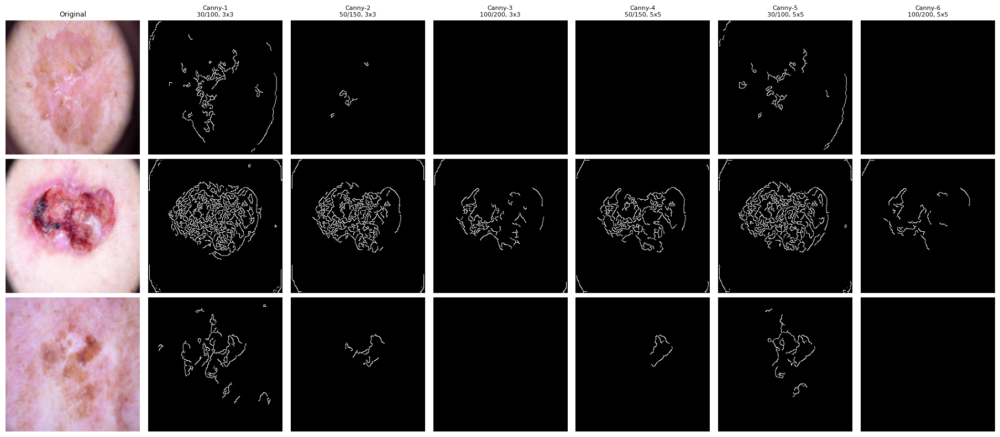

In [8]:
CFGS = [("Canny-1", 30, 100, 3), ("Canny-2", 50, 150, 3), ("Canny-3", 100, 200, 3),
        ("Canny-4", 50, 150, 5), ("Canny-5", 30, 100, 5), ("Canny-6", 100, 200, 5)]
clean_g = [gray32(X[i]) for i in sel]
noisy_g = [gray32(add_gauss(X[i], np.random.default_rng(SEED + int(i)))) for i in sel]
rows = []
for name, lo, hi, k in CFGS:
    sc = []
    for cg, ng in zip(clean_g, noisy_g):
        e = canny(cg, lo, hi, k) > 0; en = canny(ng, lo, hi, k) > 0
        s = edge_scores(e, en); s["EdgePx"] = e.sum(); s["Dens"] = 100 * e.mean(); s["Seg"] = cv2.connectedComponents(e.astype(np.uint8), connectivity=8)[0] - 1
        sc.append(s)
    m = pd.DataFrame(sc).mean()
    q = "Sparse" if m.Dens < 2 else ("Balanced" if m.Dens <= 12 else "Over-detected")
    ob = {"Sparse": "Only strongest boundaries kept; fine texture and weak lesion borders may be lost.",
          "Balanced": "Main lesion border and moderate texture retained with limited clutter.",
          "Over-detected": "Many weak/noisy edges (skin texture, hair, noise) are kept; cluttered map."}[q]
    rows.append({"Configuration": name, "Low Threshold": lo, "High Threshold": hi, "Kernel Size": f"{k}x{k}", "Edge Quality": q,
                 "Number of Detected Edges (px/img)": round(m.EdgePx), "Density %": round(m.Dens, 2), "Segments/img": round(m.Seg),
                 "Noise robustness F1": round(m.F1, 3), "Observation": ob})
t2 = pd.DataFrame(rows); display(t2); t2.to_csv(f"{OUT_DIR}/table2_canny.csv", index=False)

cand = t2[(t2["Density %"] >= 2) & (t2["Density %"] <= 12)]
if cand.empty: cand = t2
best_row = cand.loc[cand["Noise robustness F1"].idxmax()]
auto_cfg = (int(best_row["Low Threshold"]), int(best_row["High Threshold"]), int(best_row["Kernel Size"][0]))
CANNY_SEL = auto_cfg if CANNY_CFG == "auto" else tuple(CANNY_CFG)
print(f"Auto-suggested (balanced density 2-12%, highest noise robustness): {best_row.Configuration} {auto_cfg}")
print("Canny configuration used for Task 4:", CANNY_SEL, "(override with CANNY_CFG in CONFIG)")
ANS["Q3"] = (f"Raising the thresholds reduces the number of detected edge pixels: with a 3x3 kernel, (30,100) gave {t2.iloc[0]['Number of Detected Edges (px/img)']} px/image "
             f"({t2.iloc[0]['Density %']}%), (50,150) gave {t2.iloc[1]['Number of Detected Edges (px/img)']} ({t2.iloc[1]['Density %']}%) and (100,200) gave "
             f"{t2.iloc[2]['Number of Detected Edges (px/img)']} ({t2.iloc[2]['Density %']}%). Low thresholds keep weak edges (texture, hair, noise: more false/cluttered edges); "
             f"high thresholds keep only strong, clean boundaries but risk breaking contours and losing faint lesion borders. A 5x5 Gaussian kernel smooths more, giving fewer "
             f"noise-driven edges and higher noise robustness but slightly less sharp/localised edges. Selected configuration: {CANNY_SEL}.")

fig, axs = plt.subplots(3, 1 + len(CFGS), figsize=(2.6 * (1 + len(CFGS)), 8))
for r, i in enumerate(rep[:3]):
    g = gray32(big(i)); axs[r, 0].imshow(big(i)); axs[r, 0].axis("off")
    if r == 0: axs[r, 0].set_title("Original", fontsize=9)
    for c, (n, lo, hi, k) in enumerate(CFGS):
        axs[r, c + 1].imshow(canny(g, lo, hi, k), cmap="gray"); axs[r, c + 1].axis("off")
        if r == 0: axs[r, c + 1].set_title(f"{n}\n{lo}/{hi}, {k}x{k}", fontsize=8)
plt.tight_layout(); savefig("task3_canny_params"); plt.show()

## Task 4: Build the three datasets (same split for all)
Set A = Raw, Set B = Filtered (best Lab-2 filter), Set C = Edge (best edge method / configuration).

{'Raw': (10015, 128, 128, 3), 'Filtered': (10015, 128, 128, 3), 'Edge': (10015, 128, 128, 3)} | filter: Gaussian | edge: Canny (30, 100, 5)


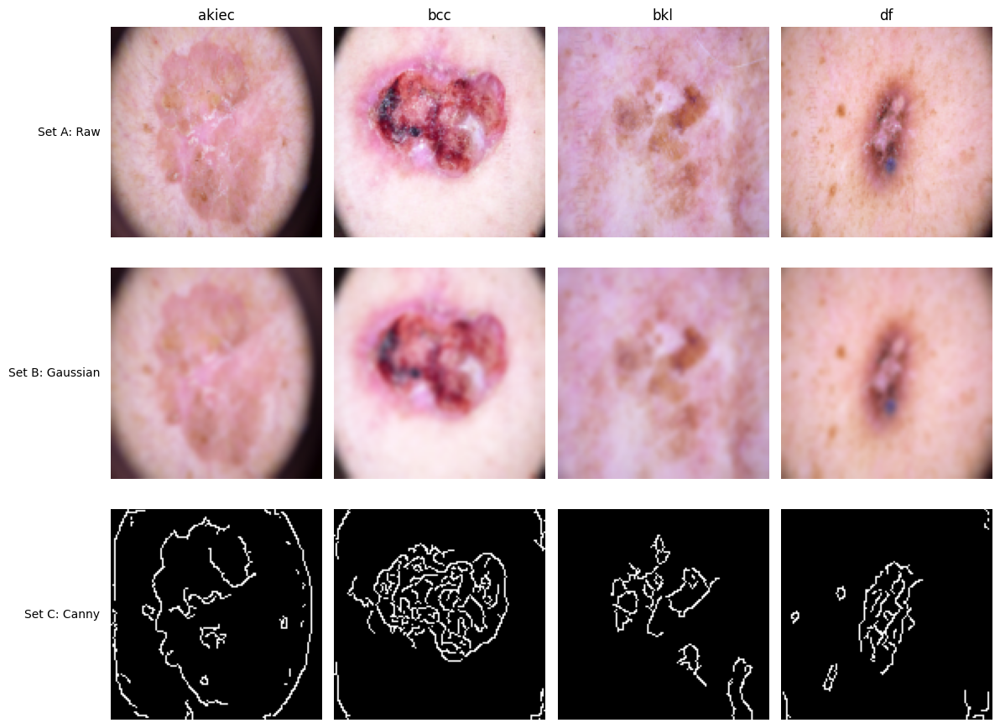

In [9]:
def edge_image(img):
    g = gray32(img)
    m = canny(g, *CANNY_SEL) if EDGE_METHOD == "Canny" else det_map(EDGE_METHOD, g)
    if EDGE_METHOD != "Canny": m = 255 * m / (m.max() + 1e-6)
    m = np.clip(m, 0, 255).astype(np.uint8); return np.stack([m] * 3, -1)
SETS = {"Raw": X, "Filtered": np.stack([apply_filter(im, BEST_FILTER) for im in X]), "Edge": np.stack([edge_image(im) for im in X])}
print({k: v.shape for k, v in SETS.items()}, "| filter:", BEST_FILTER, "| edge:", EDGE_METHOD, CANNY_SEL if EDGE_METHOD == "Canny" else "")
fig, axs = plt.subplots(3, len(rep), figsize=(3 * len(rep), 9))
for c, i in enumerate(rep):
    for r, (k, v) in enumerate(SETS.items()):
        axs[r, c].imshow(v[i], cmap="gray" if k == "Edge" else None); axs[r, c].axis("off")
        if c == 0: axs[r, c].text(-0.05, 0.5, {"Raw": "Set A: Raw", "Filtered": f"Set B: {BEST_FILTER}", "Edge": f"Set C: {EDGE_METHOD}"}[k],
                                  transform=axs[r, c].transAxes, ha="right", va="center")
        if r == 0: axs[r, c].set_title(CLASSES[y[i]])
plt.tight_layout(); savefig("task4_three_sets"); plt.show()

## Tasks 4-5: Train / evaluate SVM, Random Forest, KNN (HOG + colour-histogram features) and two CNNs on all three sets
Same train/test split for every model. CNNs use the Lab-2 training recipe (validation set selects the best epoch). Classical models train on the training set only.
Training time = fit time (CNN: all epochs incl. validation). Inference time = ms per test image for the model itself (feature extraction/preprocessing excluded).

In [10]:
import torchvision.models as tvm
MEAN = torch.tensor([0.485, 0.456, 0.406], device=dev).view(1, 3, 1, 1); STD = torch.tensor([0.229, 0.224, 0.225], device=dev).view(1, 3, 1, 1)
def sync():
    if dev.type == "cuda": torch.cuda.synchronize()
def clf_metrics(yt, yp):
    return dict(Accuracy=accuracy_score(yt, yp), Precision=precision_score(yt, yp, average="weighted", zero_division=0),
                Recall=recall_score(yt, yp, average="weighted", zero_division=0), F1=f1_score(yt, yp, average="weighted", zero_division=0),
                MacroF1=f1_score(yt, yp, average="macro", zero_division=0), BalancedAcc=balanced_accuracy_score(yt, yp))

# ---------- classical ----------
def _feat(im):
    s = cv2.resize(im, (64, 64), interpolation=cv2.INTER_AREA); g = cv2.cvtColor(s, cv2.COLOR_RGB2GRAY)
    h = hog(g, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), feature_vector=True)
    ch = np.concatenate([np.histogram(s[..., c], bins=16, range=(0, 256))[0] / 4096.0 for c in range(3)])
    return np.concatenate([h, ch]).astype(np.float32)
def features(Xa): return np.stack(Parallel(n_jobs=-1, batch_size=256)(delayed(_feat)(im) for im in Xa))
def make_clf(n):
    return {"SVM": SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced"),
            "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample", n_jobs=-1, random_state=SEED),
            "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1)}[n]
def run_classical(name, sname, Fe):
    path = f"{OUT_DIR}/runs/{name.replace(' ', '')}__{sname}.pkl"
    if os.path.exists(path): return pickle.load(open(path, "rb"))
    set_seed(SEED)
    pipe = Pipeline([("sc", StandardScaler()), ("pca", PCA(n_components=min(150, len(tr_idx) - 1, Fe.shape[1]), random_state=SEED)), ("clf", make_clf(name))])
    t = time.time(); pipe.fit(Fe[tr_idx], y[tr_idx]); tt = time.time() - t
    t = time.time(); yp = pipe.predict(Fe[te_idx]); ms = 1000 * (time.time() - t) / len(te_idx)
    r = dict(Model=name, Set=sname, **clf_metrics(y[te_idx], yp), TrainTime=tt, InferMs=ms, y_true=y[te_idx], y_pred=yp)
    pickle.dump(r, open(path, "wb")); return r

# ---------- CNN ----------
def build_model(name, nc):
    m = getattr(tvm, name)(weights="DEFAULT")
    if hasattr(m, "fc") and isinstance(m.fc, nn.Linear): m.fc = nn.Linear(m.fc.in_features, nc)
    elif isinstance(m.classifier, nn.Linear): m.classifier = nn.Linear(m.classifier.in_features, nc)
    else:
        for i in range(len(m.classifier) - 1, -1, -1):
            if isinstance(m.classifier[i], nn.Linear): m.classifier[i] = nn.Linear(m.classifier[i].in_features, nc); break
    return m.to(dev)
def prep(xb, train=False):
    xb = xb.permute(0, 3, 1, 2).float() / 255.0
    if train:
        B = xb.shape[0]
        for d in (3, 2): xb = torch.where((torch.rand(B, device=dev) < 0.5).view(B, 1, 1, 1), xb.flip(d), xb)
    return (xb - MEAN) / STD
@torch.no_grad()
def predict(model, Xt, yt, idx):
    model.eval(); P, loss = [], 0.0
    for i in range(0, len(idx), 256):
        b = idx[i:i + 256]
        with torch.autocast(dev.type, enabled=dev.type == "cuda"): out = model(prep(Xt[b]))
        loss += F.cross_entropy(out.float(), yt[b], reduction="sum").item(); P.append(F.softmax(out.float(), 1).cpu().numpy())
    return np.concatenate(P), loss / len(idx)
def run_cnn(mname, sname, Xt, yt):
    path = f"{OUT_DIR}/runs/cnn__{mname}__{sname}.pkl"
    if os.path.exists(path): return pickle.load(open(path, "rb"))
    set_seed(SEED); model = build_model(mname, NC)
    cw = torch.tensor(len(tr_idx) / (NC * np.bincount(y[tr_idx], minlength=NC).clip(1)), dtype=torch.float32, device=dev)
    crit = nn.CrossEntropyLoss(weight=cw); opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=EPOCHS * int(np.ceil(len(tr_idx) / BATCH_SIZE)))
    scaler = torch.cuda.amp.GradScaler(enabled=dev.type == "cuda")
    tr_t, va_t, te_t = [torch.tensor(i, device=dev) for i in (tr_idx, va_idx, te_idx)]
    best, best_state = -1, None; sync(); t0 = time.time()
    for ep in range(EPOCHS):
        model.train(); perm = tr_t[torch.randperm(len(tr_t), device=dev)]
        for i in range(0, len(perm), BATCH_SIZE):
            b = perm[i:i + BATCH_SIZE]
            with torch.autocast(dev.type, enabled=dev.type == "cuda"): loss = crit(model(prep(Xt[b], True)).float(), yt[b])
            opt.zero_grad(set_to_none=True); scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
        Pv, _ = predict(model, Xt, yt, va_t); vf = f1_score(y[va_idx], Pv.argmax(1), average="macro", zero_division=0)
        if vf > best: best = vf; best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    sync(); tt = time.time() - t0
    model.load_state_dict(best_state); predict(model, Xt, yt, te_t[:64])          # warm-up
    sync(); t = time.time(); Pt, _ = predict(model, Xt, yt, te_t); sync(); ms = 1000 * (time.time() - t) / len(te_idx)
    r = dict(Model=f"CNN: {pretty.get(mname, mname)}", Set=sname, **clf_metrics(y[te_idx], Pt.argmax(1)), TrainTime=tt, InferMs=ms, y_true=y[te_idx], y_pred=Pt.argmax(1))
    pickle.dump(r, open(path, "wb")); del model, opt; torch.cuda.empty_cache(); return r

results = []; yt_all = torch.tensor(y, device=dev); T0 = time.time()
for sname, arr in SETS.items():
    print(f"\n=== Set: {sname} ==="); t = time.time(); Fe = features(arr); print(f"features {Fe.shape} in {time.time()-t:.0f}s")
    for cn in ["SVM", "Random Forest", "KNN"]:
        r = run_classical(cn, sname, Fe); results.append(r)
        print(f"  {r['Model']:22s} acc={r['Accuracy']:.4f} F1={r['F1']:.4f} train={r['TrainTime']:.1f}s infer={r['InferMs']:.3f}ms")
    Xt = torch.from_numpy(arr).to(dev)
    for mn in MODEL_NAMES:
        r = run_cnn(mn, sname, Xt, yt_all); results.append(r)
        print(f"  {r['Model']:22s} acc={r['Accuracy']:.4f} F1={r['F1']:.4f} macroF1={r['MacroF1']:.4f} train={r['TrainTime']:.0f}s infer={r['InferMs']:.3f}ms")
    del Xt; torch.cuda.empty_cache()
print(f"\nTotal: {(time.time()-T0)/60:.1f} min")


=== Set: Raw ===
features (10015, 1812) in 24s
  SVM                    acc=0.7051 F1=0.6835 train=10.2s infer=1.433ms
  Random Forest          acc=0.6759 F1=0.5454 train=35.3s infer=0.166ms
  KNN                    acc=0.6301 F1=0.6234 train=2.4s infer=0.177ms
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 154MB/s]


  CNN: ResNet50          acc=0.7800 F1=0.7937 macroF1=0.6042 train=70s infer=0.424ms
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 103MB/s]


  CNN: DenseNet121       acc=0.7696 F1=0.7848 macroF1=0.6673 train=97s infer=0.596ms

=== Set: Filtered ===
features (10015, 1812) in 23s
  SVM                    acc=0.6940 F1=0.6669 train=9.9s infer=1.249ms
  Random Forest          acc=0.6759 F1=0.5452 train=33.9s infer=0.124ms
  KNN                    acc=0.6218 F1=0.6088 train=3.5s infer=0.216ms
  CNN: ResNet50          acc=0.7647 F1=0.7819 macroF1=0.6117 train=70s infer=0.359ms
  CNN: DenseNet121       acc=0.7495 F1=0.7659 macroF1=0.6359 train=108s infer=0.507ms

=== Set: Edge ===
features (10015, 1812) in 21s
  SVM                    acc=0.5725 F1=0.5616 train=13.7s infer=2.061ms
  Random Forest          acc=0.6384 F1=0.5357 train=32.7s infer=0.130ms
  KNN                    acc=0.6003 F1=0.5625 train=2.0s infer=0.162ms
  CNN: ResNet50          acc=0.4670 F1=0.5323 macroF1=0.2639 train=70s infer=0.361ms
  CNN: DenseNet121       acc=0.4670 F1=0.5359 macroF1=0.2768 train=97s infer=0.505ms

Total: 12.3 min


## Task 5: Table 3 (cross-lab performance comparison)
Raw = Lab 1 setting, Filtered = Lab 2 best filter, Edge = Lab 3. All three are re-trained here on the identical split for a fair comparison.
In Table 3, Precision / Recall / F1 / times refer to the **Edge set (Lab 3)**; the full table below gives every metric for every set.

In [11]:
full = pd.DataFrame([{k: v for k, v in r.items() if k not in ("y_true", "y_pred")} for r in results])
ORDER = ["SVM", "Random Forest", "KNN"] + [f"CNN: {pretty.get(m, m)}" for m in MODEL_NAMES]
full["Model"] = pd.Categorical(full.Model, ORDER, ordered=True); full["Set"] = pd.Categorical(full.Set, ["Raw", "Filtered", "Edge"], ordered=True)
full = full.sort_values(["Model", "Set"]).reset_index(drop=True)
rows = []
for mname in ORDER:
    d = full[full.Model == mname].set_index("Set"); e = d.loc["Edge"]
    label = mname if not mname.startswith("CNN") else f"CNN Model {ORDER.index(mname) - 2} ({mname[5:]})"
    rows.append({"Model / Classifier": label, "Accuracy Raw (Lab 1)": d.loc["Raw", "Accuracy"], "Accuracy Filtered (Lab 2)": d.loc["Filtered", "Accuracy"],
                 "Accuracy Edge (Lab 3)": e.Accuracy, "Precision": e.Precision, "Recall": e.Recall, "F1-Score": e.F1,
                 "Training Time (s)": e.TrainTime, "Inference Time (ms)": e.InferMs})
t3 = pd.DataFrame(rows)
print("TABLE 3 (Precision/Recall/F1 weighted, times for Edge set)")
display(t3.style.format({c: "{:.4f}" for c in t3.columns[1:7]} | {"Training Time (s)": "{:.1f}", "Inference Time (ms)": "{:.3f}"}))
print("FULL TABLE (all models x all sets)")
display(full.style.format({c: "{:.4f}" for c in ["Accuracy", "Precision", "Recall", "F1", "MacroF1", "BalancedAcc"]} | {"TrainTime": "{:.1f}", "InferMs": "{:.3f}"}))
t3.to_csv(f"{OUT_DIR}/table3.csv", index=False); full.to_csv(f"{OUT_DIR}/table3_full.csv", index=False)
print(f"Filtered set = {BEST_FILTER}; Edge set = {EDGE_METHOD} {CANNY_SEL if EDGE_METHOD == 'Canny' else ''}")

TABLE 3 (Precision/Recall/F1 weighted, times for Edge set)


,Model / Classifier,Accuracy Raw (Lab 1),Accuracy Filtered (Lab 2),Accuracy Edge (Lab 3),Precision,Recall,F1-Score,Training Time (s),Inference Time (ms)
0,SVM,0.7051,0.6940,0.5725,0.5599,0.5725,0.5616,13.7,2.061
1,Random Forest,0.6759,0.6759,0.6384,0.4654,0.6384,0.5357,32.7,0.130
2,KNN,0.6301,0.6218,0.6003,0.5380,0.6003,0.5625,2.0,0.162
3,CNN Model 1 (ResNet50),0.7800,0.7647,0.4670,0.6915,0.4670,0.5323,69.9,0.361
4,CNN Model 2 (DenseNet121),0.7696,0.7495,0.4670,0.7000,0.4670,0.5359,96.6,0.505


FULL TABLE (all models x all sets)


,Model,Set,Accuracy,Precision,Recall,F1,MacroF1,BalancedAcc,TrainTime,InferMs
0,SVM,Raw,0.7051,0.6677,0.7051,0.6835,0.3022,0.3066,10.2,1.433
1,SVM,Filtered,0.6940,0.6479,0.6940,0.6669,0.2806,0.2785,9.9,1.249
2,SVM,Edge,0.5725,0.5599,0.5725,0.5616,0.2114,0.2416,13.7,2.061
3,Random Forest,Raw,0.6759,0.4572,0.6759,0.5454,0.1153,0.1429,35.3,0.166
4,Random Forest,Filtered,0.6759,0.4569,0.6759,0.5452,0.1152,0.1429,33.9,0.124
5,Random Forest,Edge,0.6384,0.4654,0.6384,0.5357,0.1218,0.1413,32.7,0.130
6,KNN,Raw,0.6301,0.6344,0.6301,0.6234,0.2475,0.2663,2.4,0.177
7,KNN,Filtered,0.6218,0.6097,0.6218,0.6088,0.2145,0.2541,3.5,0.216
8,KNN,Edge,0.6003,0.5380,0.6003,0.5625,0.1643,0.1681,2.0,0.162
9,CNN: ResNet50,Raw,0.7800,0.8183,0.7800,0.7937,0.6042,0.6402,70.1,0.424


Filtered set = Gaussian; Edge set = Canny (30, 100, 5)


## Task 6: Visual comparison for the best-performing model

Best-performing model (highest mean weighted-F1 over the three sets): CNN: ResNet50


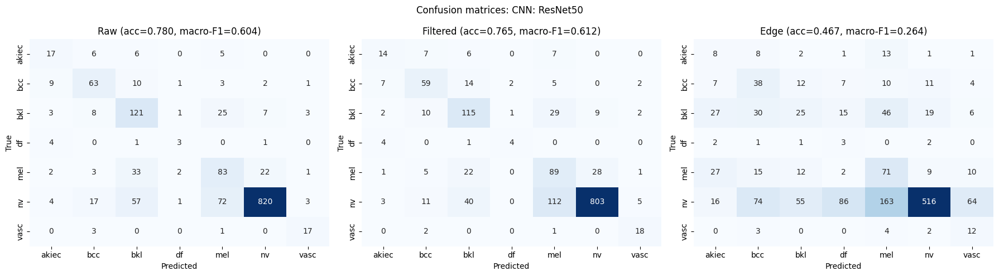

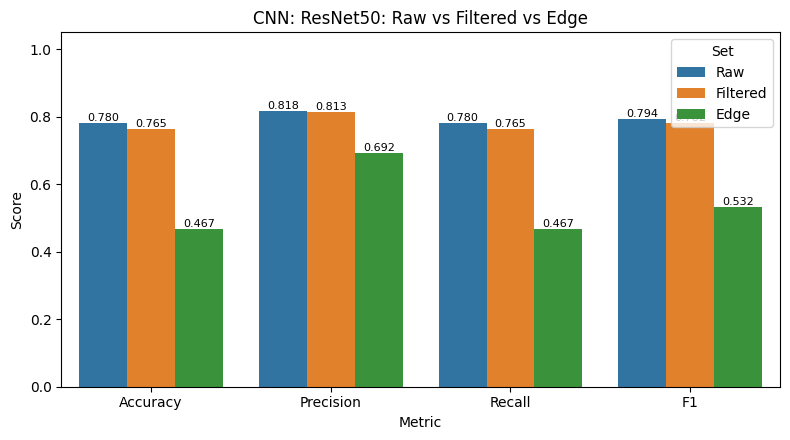

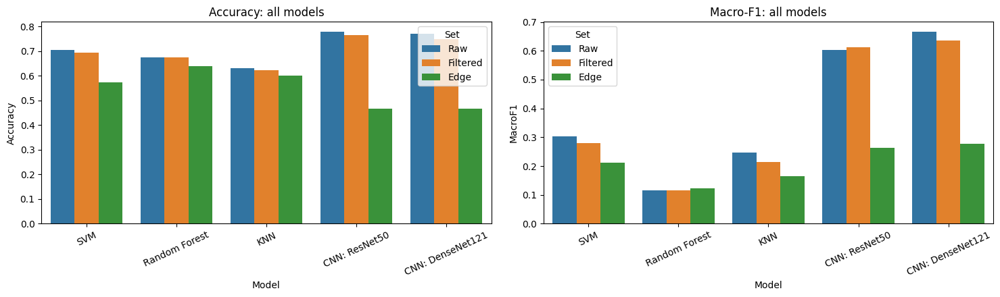

In [12]:
best_model = str(full.groupby("Model", observed=True).F1.mean().idxmax())
print("Best-performing model (highest mean weighted-F1 over the three sets):", best_model)
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for a, sname in zip(axs, ["Raw", "Filtered", "Edge"]):
    r = [r for r in results if r["Model"] == best_model and r["Set"] == sname][0]
    sns.heatmap(confusion_matrix(r["y_true"], r["y_pred"], labels=range(NC)), annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=a, cbar=False)
    a.set_title(f"{sname} (acc={r['Accuracy']:.3f}, macro-F1={r['MacroF1']:.3f})"); a.set_xlabel("Predicted"); a.set_ylabel("True")
plt.suptitle(f"Confusion matrices: {best_model}"); plt.tight_layout(); savefig("task6_confusion_matrices"); plt.show()

bm = full[full.Model == best_model].melt(id_vars="Set", value_vars=["Accuracy", "Precision", "Recall", "F1"], var_name="Metric", value_name="Score")
plt.figure(figsize=(8, 4.5)); ax = sns.barplot(data=bm, x="Metric", y="Score", hue="Set")
for c in ax.containers: ax.bar_label(c, fmt="%.3f", fontsize=8)
plt.ylim(0, 1.05); plt.title(f"{best_model}: Raw vs Filtered vs Edge"); plt.tight_layout(); savefig("task6_bar_chart"); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
sns.barplot(data=full, x="Model", y="Accuracy", hue="Set", ax=ax[0]); ax[0].tick_params(axis="x", rotation=25); ax[0].set_title("Accuracy: all models")
sns.barplot(data=full, x="Model", y="MacroF1", hue="Set", ax=ax[1]); ax[1].tick_params(axis="x", rotation=25); ax[1].set_title("Macro-F1: all models")
plt.tight_layout(); savefig("all_models_comparison"); plt.show()

## Discussion answers (numbers are computed from YOUR results)

In [13]:
nz = t1[(t1.Input == "Noisy") & (t1["Preprocessing"] == "None")].assign(FE=lambda d: 1 - d.Precision).groupby("Edge Detector").agg(F1=("F1", "mean"), FE=("FE", "mean"))
most = nz.F1.idxmin(); ANS["Q1"] = (f"Under unfiltered noise the mean edge F1 (vs clean edges) was: " + ", ".join(f"{d} {nz.F1[d]:.2f} ({100*nz.FE[d]:.0f}% false edges)" for d in nz.index) +
    f". The most noise-sensitive detector was {most}. Second-derivative operators (Laplacian, LoG without enough smoothing) amplify noise because differentiation boosts high frequencies; "
    f"first-order Sobel/Prewitt average over a 3x3 window so are more tolerant, and Canny is robust owing to built-in smoothing and hysteresis thresholding.")
fl = t1[(t1.Input == "Noisy")].groupby(["Noise Type", "Preprocessing"]).F1.mean().unstack()[["None", "Gaussian Filter", "Median Filter"]]
ANS["Q2"] = ("Mean edge F1 over all detectors:\n" + fl.round(3).to_string() +
    "\nGaussian filtering suppresses Gaussian noise (averaging) but blurs and widens edges (less sharp, small details lost). Median filtering removes impulse (salt-and-pepper) "
    "noise while preserving edges better, so it is usually best for salt-and-pepper noise; it is less effective than Gaussian for Gaussian noise. Either filter lowers false edges and fragmentation.")
d_ = full.pivot_table(index="Model", columns="Set", values="Accuracy", observed=True); d_["Edge-Raw"] = d_.Edge - d_.Raw
worse = int((d_["Edge-Raw"] < 0).sum())
ANS["Q4"] = ("Accuracy by model and input set:\n" + d_.round(4).to_string() +
    f"\nEdge images lowered accuracy versus raw for {worse}/{len(d_)} models (mean change {d_['Edge-Raw'].mean():+.4f}). " +
    ("Possible reasons: edge maps discard colour, intensity and internal texture; binary/thin edges are sparse and sensitive to threshold and noise; and a pretrained CNN expects natural RGB images (domain shift)."
     if worse >= len(d_) / 2 else "Edges apparently kept enough boundary/texture cues for these models; still, colour and shading information is removed, so gains (if any) should be interpreted cautiously."))
ANS["Q5"] = ("Edge maps keep only local intensity discontinuities. Lost: colour (number/distribution of colours, e.g. blue-white veil, red/black areas: key diagnostic cues), absolute intensity and shading "
    "(darkness, depth), smooth internal texture and homogeneous regions (pigment network density, structureless areas), and the sign/strength of contrast unless magnitudes are kept. Thresholded (Canny) edges "
    "also lose edge strength, and weak borders may vanish. Global shape survives, but for lesions colour and texture are as important as boundaries.")
ANS["Q6"] = ("Learned features are (1) task-optimised: filters are chosen to minimise the classification loss, not fixed by hand; (2) richer: they capture colour, texture, blobs, "
    "and higher-level patterns, not only boundaries; (3) hierarchical: early edge-like filters are combined into complex lesion-specific patterns; (4) adaptive: they handle noise, illumination and "
    "scale variation and need no threshold tuning; (5) end-to-end, so no information is discarded before the classifier can use it; (6) they exploit transfer learning from ImageNet. "
    "Manual edge maps add pipeline complexity and parameter sensitivity, and irreversibly remove information.")
sm = full.groupby("Set", observed=True)[["Accuracy", "MacroF1", "BalancedAcc", "F1"]].mean(); bs = sm.MacroF1.idxmax()
ANS["Q7"] = ("Mean over all models:\n" + sm.round(4).to_string() + f"\nBest representation by mean Macro-F1: **{bs}** (by mean accuracy: {sm.Accuracy.idxmax()}). "
    "Per model (accuracy):\n" + d_[["Raw", "Filtered", "Edge"]].round(4).to_string() +
    "\nJustify your choice with these numbers, together with the Lab 1-2 results, and mention that the differences should be judged against run-to-run variance (single seed).")
for q in ["Q1", "Q2", "Q3", "Q4", "Q5", "Q6", "Q7"]: print(f"\n===== Question {q[1]} =====\n{ANS[q]}")


===== Question 1 =====
Under unfiltered noise the mean edge F1 (vs clean edges) was: Canny 0.24 (85% false edges), Laplacian 0.52 (45% false edges), LoG 0.62 (49% false edges), Prewitt 0.51 (59% false edges), Sobel 0.50 (60% false edges). The most noise-sensitive detector was Canny. Second-derivative operators (Laplacian, LoG without enough smoothing) amplify noise because differentiation boosts high frequencies; first-order Sobel/Prewitt average over a 3x3 window so are more tolerant, and Canny is robust owing to built-in smoothing and hysteresis thresholding.

===== Question 2 =====
Mean edge F1 over all detectors:
Preprocessing   None  Gaussian Filter  Median Filter
Noise Type                                          
Gaussian       0.546            0.649          0.601
Salt & Pepper  0.408            0.553          0.708
Gaussian filtering suppresses Gaussian noise (averaging) but blurs and widens edges (less sharp, small details lost). Median filtering removes impulse (salt-and-p

## Viva questions: model answers
1. **Edge**: a location where image intensity (or colour/texture) changes abruptly, i.e. a large local gradient, typically at object boundaries.
2. **First vs second order**: first-order detectors (Sobel, Prewitt) find maxima of the gradient magnitude; second-order detectors (Laplacian, LoG) find zero-crossings of the second derivative. First-order gives thick edges and direction; second-order gives thin edges but is more noise-sensitive.
3. **Sobel Gx vs Gy**: Gx differentiates horizontally and highlights vertical edges; Gy differentiates vertically and highlights horizontal edges. Magnitude sqrt(Gx^2+Gy^2) combines them.
4. **Laplacian noise sensitivity**: it is a second derivative (high-pass), so it amplifies high-frequency noise strongly, and it has no smoothing or averaging.
5. **Gaussian smoothing before edge detection**: suppresses noise so that derivatives do not respond to it; scale (sigma) controls which edge size is detected (as in LoG and Canny).
6. **Canny advantage**: good detection (low error rate), good localisation, single response per edge (thin edges via non-maximum suppression), and robustness via smoothing and hysteresis.
7. **Canny thresholds**: pixels with gradient above the high threshold are strong edges; below the low threshold are discarded; in-between pixels are kept only if connected to strong edges (hysteresis).
8. **Gaussian vs salt-and-pepper noise**: Gaussian noise perturbs every pixel with normally distributed values (additive, continuous); salt-and-pepper replaces a fraction of pixels with extreme values 0 or 255 (impulse noise).
9. **Median filter for salt-and-pepper**: impulses are outliers, so the median ignores them and replaces them with a neighbouring typical value, while preserving edges (unlike the mean).
10. **Why edges can reduce accuracy**: colour, intensity and texture are removed; edge maps are sparse, threshold- and noise-sensitive, and differ from the natural images used in pretraining.
11. **Can a CNN learn edges?** Yes. First-layer filters of trained CNNs resemble Gabor/Sobel-like oriented edge and colour-blob detectors, learned automatically.
12. **Raw better than edge-only**: raw images contain all information (colour, texture, shading) and match the pretrained distribution; the CNN can derive whatever edge information it needs.

## Auto-generated report and download

In [14]:
def md(df):
    try: return df.to_markdown(index=False, floatfmt=".4f")
    except Exception: return df.to_string(index=False)
rep_md = f"""# Lab 03: Edge Detection Techniques and Their Impact on Classification Performance

## 1. Introduction
Edges mark abrupt intensity changes and describe object boundaries. This lab implements first-order (Sobel, Prewitt), second-order (Laplacian, LoG) and multi-stage (Canny) edge detectors, studies their behaviour under Gaussian and salt-and-pepper noise, analyses Canny parameters, and measures how raw, filtered and edge-only inputs affect skin-lesion classification on HAM10000.

## 2. Methodology
Detectors: Sobel (Gx, Gy, magnitude), Prewitt, Laplacian (3x3), LoG (sigma 1.4), Canny (Gaussian smoothing + gradient + non-maximum suppression + hysteresis). Noise: Gaussian (sigma {NOISE_SIGMA}) and salt-and-pepper ({int(SP_AMOUNT*100)}% pixels). Preprocessing: Gaussian 5x5 (sigma 1.5), Median 5x5. Edge quality was measured as F1 of a noisy-input edge map against the clean-input edge map (1 px tolerance), noise sensitivity as the fraction of false edge pixels (1 - precision), and fragmentation as connected segments per 1000 edge pixels.

## 3. Experimental setup
Dataset: HAM10000, {len(meta)} images, classes {CLASSES}, resized to {IMG_SIZE}x{IMG_SIZE}. Lesion-grouped stratified split: train {len(tr_idx)} / validation {len(va_idx)} / test {len(te_idx)}. Set A raw; Set B filtered ({BEST_FILTER}); Set C edges ({EDGE_METHOD}{', Canny ' + str(CANNY_SEL) if EDGE_METHOD == 'Canny' else ''}).
Classical models (SVM-RBF, Random Forest, KNN) use HOG + colour histograms, standardisation and PCA(150). CNNs ({', '.join(pretty.get(m, m) for m in MODEL_NAMES)}) are ImageNet-pretrained, fine-tuned for {EPOCHS} epochs (AdamW, lr {LR}, class-weighted loss, flips), best epoch by validation macro-F1. Metrics: accuracy, weighted precision/recall/F1, macro-F1, balanced accuracy; training and inference time.

## 4. Results
### Table 1 (required rows)
{md(t1_req)}

### Table 2: Canny parameters
{md(t2)}

### Table 3: Cross-lab performance (P/R/F1/times for edge set)
{md(t3)}

### Full results
{md(full)}

Figures are in the `figs/` folder (edge detectors, noise, Canny parameters, three datasets, confusion matrices, bar charts).

## 5. Discussion
""" + "\n\n".join(f"**Question {q[1]}.**\n\n{ANS[q]}" for q in ["Q1", "Q2", "Q3", "Q4", "Q5", "Q6", "Q7"]) + """

## 6. Conclusion
Summarise in 3-4 sentences: which detector was most robust to noise, which preprocessing helped, which Canny setting was best, and which input representation (raw / filtered / edge) gave the best classification performance, with the supporting numbers above.

## 7. References
1. J. Canny, "A computational approach to edge detection," IEEE TPAMI, 8(6), 679-698, 1986.
2. D. Marr and E. Hildreth, "Theory of edge detection," Proc. R. Soc. Lond. B, 207, 187-217, 1980.
3. P. Tschandl, C. Rosendahl, H. Kittler, "The HAM10000 dataset," Scientific Data, 5:180161, 2018.
4. R. C. Gonzalez and R. E. Woods, Digital Image Processing, 4th ed., Pearson, 2018.
5. K. He et al., "Deep residual learning for image recognition," CVPR, 2016.
"""
open(f"{OUT_DIR}/report.md", "w").write(rep_md)
zp = "/content/lab03_results.zip"
with zipfile.ZipFile(zp, "w", zipfile.ZIP_DEFLATED) as z:
    for root, _, files in os.walk(OUT_DIR):
        for f in files:
            if not f.endswith(".pkl"): z.write(os.path.join(root, f), os.path.relpath(os.path.join(root, f), OUT_DIR))
print("Saved", zp, "(contains report.md, tables CSV, all figures)")
try:
    from google.colab import files; files.download(zp)
except Exception: pass

Saved /content/lab03_results.zip (contains report.md, tables CSV, all figures)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>